# Episode Reward Computation and Visualization

This notebook preprocesses rosbag data (converted to HDF5) and computes multi-component rewards for SPOT robot episodes.

**Note on ROS Conversion:** Converting rosbags directly requires ROS/rosbag2 packages. If those aren't available in your environment, convert rosbags using the `convert_bag_to_hdf5.py` script first, then load the resulting HDF5 files here.

## Reward Components:
1. **Goal Reaching Reward:** +5 when robot reaches goal position
2. **Distance Decrease Reward:** Continuous reward for moving closer to goal (primary signal)
3. **Obstacle Collision Penalty:** Penalizes proximity to obstacles (>30cm height)
4. **Jerk Penalty:** Penalizes large acceleration changes (smooth motion)
5. **Gait Switching Penalty:** Penalizes switching between gaits (energy efficiency)
6. **Instability Penalty:** Penalizes large rotations/tilting (stable motion)

## Section 1: Load and Convert HDF5 Data

In [23]:
import os
import glob
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [24]:
# Configuration
RECORDED_DATA_DIR = "/home/maurits-heemskerk/Documents/Uni/Master_Thesis/openbots_backpack/src/packages/dataset/recorded_data"

# Find all HDF5 files and ROS bags
h5_files = glob.glob(os.path.join(RECORDED_DATA_DIR, "**/*.h5"), recursive=True)
bag_dirs = [d for d in glob.glob(os.path.join(RECORDED_DATA_DIR, "*")) if os.path.isdir(d)]

print(f"Found {len(h5_files)} HDF5 files")
print(f"Found {len(bag_dirs)} ROS bag directories")

if h5_files:
    print("\nHDF5 Files:")
    for f in sorted(h5_files, key=os.path.getmtime, reverse=True):
        size_mb = os.path.getsize(f) / (1024**2)
        print(f"  - {os.path.basename(f)} ({size_mb:.2f} MB)")
        
if bag_dirs:
    print("\nROS Bag Directories:")
    for d in sorted(bag_dirs, key=os.path.getmtime, reverse=True)[:5]:
        print(f"  - {os.path.basename(d)}")

Found 3 HDF5 files
Found 35 ROS bag directories

HDF5 Files:
  - spot_bag_20260217_135959_expert_med_converted.h5 (52.13 MB)
  - spot_bag_20260217_125326_expert_med_converted.h5 (77.75 MB)
  - spot_bag_20260217_122532_expert_med_converted.h5 (97.28 MB)

ROS Bag Directories:
  - spot_bag_20260217_135959_expert_med
  - spot_bag_20260217_135902_expert_med
  - spot_bag_20260217_135841_expert_med
  - spot_bag_20260217_135819_expert_med
  - spot_bag_20260217_135703_expert_med


In [25]:
def load_h5_episode(h5_path, max_retries=3, retry_delay=1.0):
    """Load episode data from HDF5 file with retry logic for locked files"""
    import time
    print(f"Loading: {os.path.basename(h5_path)}")
    
    # Retry logic in case file is locked
    for attempt in range(max_retries):
        try:
            episode = {}
            with h5py.File(h5_path, 'r', swmr=False) as f:
                # Print available datasets
                print("Available datasets:")
                def print_structure(name, obj):
                    if isinstance(obj, h5py.Dataset):
                        print(f"  {name}: shape={obj.shape}, dtype={obj.dtype}")
                f.visititems(print_structure)
                
                # Load observations
                obs_keys = ['state', 'velocities', 'actions', 'timestamps', 'locomotion_mode']
                for key in obs_keys:
                    path = f'observations/{key}' if 'observations' in f else key
                    if path in f:
                        episode[key] = f[path][()]
                    elif key in f:
                        episode[key] = f[key][()]
                    else:
                        if key != 'locomotion_mode':  # Don't warn about optional locomotion_mode
                            print(f"  Warning: {key} not found")
                
                # Load actions separately
                if 'actions' not in episode and 'actions' in f:
                    episode['actions'] = f['actions'][()]
                
                # Load local grids
                if 'observations/obstacle_grids' in f:
                    episode['obstacle_grids'] = f['observations/obstacle_grids'][()]
                if 'observations/terrain_grids' in f:
                    episode['terrain_grids'] = f['observations/terrain_grids'][()]
                
                # Load images if needed (optional for reward computation)
                if 'observations/image' in f:
                    print(f"  Images available: shape={f['observations/image'].shape}")
            
            return episode
        except (BlockingIOError, OSError) as e:
            if attempt < max_retries - 1:
                print(f"  File locked (attempt {attempt+1}/{max_retries}), retrying in {retry_delay}s...")
                time.sleep(retry_delay)
            else:
                print(f"  ✗ Failed to load file after {max_retries} attempts: {e}")
                raise

# Select the latest HDF5 file if available
if h5_files:
    selected_h5 = sorted(h5_files, key=os.path.getmtime, reverse=True)[0]
    print(f"\nLoading latest HDF5: {selected_h5}")
    episode_data = load_h5_episode(selected_h5)
    data_loaded_from = "H5"
else:
    print("No HDF5 files found. You'll need to convert a rosbag first.")
    print("Run: python convert_bag_to_hdf5.py <bag_path> --output <output_dir>")
    episode_data = None
    data_loaded_from = None


Loading latest HDF5: /home/maurits-heemskerk/Documents/Uni/Master_Thesis/openbots_backpack/src/packages/dataset/recorded_data/spot_bag_20260217_135959_expert_med/spot_bag_20260217_135959_expert_med_converted.h5
Loading: spot_bag_20260217_135959_expert_med_converted.h5
Available datasets:
  actions: shape=(38, 6), dtype=float32
  observations/depth_registered_left: shape=(38, 480, 640), dtype=uint16
  observations/depth_registered_right: shape=(38, 480, 640), dtype=uint16
  observations/images_front: shape=(38, 1662, 640, 3), dtype=uint8
  observations/locomotion_mode: shape=(38,), dtype=uint32
  observations/state: shape=(38, 7), dtype=float32
  observations/terrain_grids: shape=(38, 128, 128), dtype=float32
  observations/velocities: shape=(38, 6), dtype=float32
  timestamps: shape=(38,), dtype=float64


In [26]:
# Extract episode components
if episode_data:
    timestamps = episode_data.get('timestamps', np.arange(len(episode_data['state'])))
    states = episode_data['state']  # [N, 7] = [x, y, z, qx, qy, qz, qw]
    velocities = episode_data.get('velocities', None)  # [N, 6]
    actions = episode_data.get('actions', None)  # [N, 6]
    # Try both 'terrain_grids' and 'obstacle_grids' keys (depends on converter version)
    obstacle_grids = episode_data.get('terrain_grids', episode_data.get('obstacle_grids', None))  # [N, H, W]
    
    n_steps = len(states)
    print(f"\nEpisode Summary:")
    print(f"  Steps: {n_steps}")
    print(f"  State shape: {states.shape}")
    print(f"  Velocities: {velocities.shape if velocities is not None else 'Not available'}")
    print(f"  Actions: {actions.shape if actions is not None else 'Not available'}")
    print(f"  Obstacle grids: {obstacle_grids.shape if obstacle_grids is not None else 'Not available'}")
    print(f"  Time range: {timestamps[0]:.2f} to {timestamps[-1]:.2f} seconds")
else:
    n_steps = 0
    print("No episode data loaded")


Episode Summary:
  Steps: 38
  State shape: (38, 7)
  Velocities: (38, 6)
  Actions: (38, 6)
  Obstacle grids: (38, 128, 128)
  Time range: 1771336800.63 to 1771336812.03 seconds


## Section 2: Compute Reward Components

We'll implement individual reward functions for each component, then combine them.

In [27]:
class RewardComputer:
    """Computes multi-component rewards for SPOT robot episodes"""
    
    def __init__(self, goal_threshold=0.3, goal_reward=10.0, jerk_scale=0.001, obstacle_scale=1.0, 
                 distance_reward_scale=2.0, gait_switch_penalty=0.5, instability_scale=0.001):
        self.goal_position = None
        self.goal_threshold = goal_threshold  # Distance threshold for goal reaching
        self.goal_reward = goal_reward  # Reward for reaching goal (one-time bonus)
        self.jerk_scale = jerk_scale  # Scale for jerk penalty on action commands (0.01)
        self.obstacle_scale = obstacle_scale  # Scale for obstacle penalty
        self.distance_reward_scale = distance_reward_scale  # Scale for distance decrease reward (2.0)
        self.gait_switch_penalty = gait_switch_penalty  # Penalty per gait switch
        self.instability_scale = instability_scale  # Scale for instability (angular velocity changes)
    
    def goal_reaching_reward_array(self, states):
        """
        Goal reaching reward: +goal_reward ONCE when first entering goal region
        One-time bonus when robot first reaches the goal (not per frame)
        
        Args:
            states: [N, 7] state array with positions [x, y, z, qx, qy, qz, qw]
        Returns:
            [N] array with single reward spike at first goal achievement
        """
        if self.goal_position is None or states is None or len(states) == 0:
            return np.zeros(len(states) if states is not None else 0)
        
        positions = states[:, :3]
        goal_pos = np.array(self.goal_position[:3])
        
        # Compute distances to goal at each timestep
        distances = np.linalg.norm(positions - goal_pos, axis=1)
        
        # Find first timestep where robot enters goal region
        in_goal_region = distances < self.goal_threshold
        goal_rewards = np.zeros(len(states))
        
        # Only reward at the first entry into goal region
        if np.any(in_goal_region):
            first_goal_idx = np.argmax(in_goal_region)
            goal_rewards[first_goal_idx] = self.goal_reward
        
        return goal_rewards
    
    def action_smoothness_penalty(self, actions):
        """
        Action smoothness penalty: penalizes jerky commands from the policy
        Computed from actor's control commands, not odometry (fairer metric)
        Large changes in consecutive actions indicate jerky policy outputs
        
        Args:
            actions: [N, 6] action array (policy outputs: velocities/accelerations)
        Returns:
            [N] array of action jerk penalties
        """
        if actions is None or len(actions) < 2:
            return np.zeros(len(actions) if actions is not None else 0)
        
        # Compute action differences (command jerk/acceleration)
        action_diffs = np.diff(actions, axis=0)
        
        # Magnitude of action change at each timestep
        action_change_magnitude = np.linalg.norm(action_diffs, axis=1)
        
        # Apply sqrt for sublinear penalty (gentler on large changes)
        jerk_penalties = -self.jerk_scale * np.sqrt(action_change_magnitude)
        
        # Pad to match input length
        jerk_penalties = np.pad(jerk_penalties, (1, 0), mode='constant', constant_values=0)
        return jerk_penalties
    
    def obstacle_avoidance_penalty(self, obstacle_grids, robot_height_offset=-0.8, obstacle_threshold=0.3):
        """
        Obstacle penalty: penalizes proximity to obstacles (>30cm above ground)
        
        Args:
            obstacle_grids: [N, H, W] obstacle height grids (relative to robot center)
            robot_height_offset: Robot center height above ground (default: -0.8m for SPOT)
            obstacle_threshold: Height above ground to consider as obstacle (default: 0.3m = 30cm)
        Returns:
            [N] array of obstacle penalties
        """
        if obstacle_grids is None or len(obstacle_grids) == 0:
            return np.zeros(len(obstacle_grids) if obstacle_grids is not None else 0)
        
        # Convert obstacle threshold to robot-relative coordinates
        # If robot center is -0.8m above ground, and we want 30cm above ground,
        # that's -0.8 + 0.3 = -0.5m in robot-relative coordinates
        obstacle_height_threshold = robot_height_offset + obstacle_threshold
        
        penalties = []
        for grid in obstacle_grids:
            if grid.size == 0:
                penalties.append(0.0)
            else:
                # Find minimum height in grid that exceeds obstacle threshold
                obstacles_above_threshold = grid[grid > obstacle_height_threshold]
                
                if len(obstacles_above_threshold) > 0:
                    # Find closest obstacle (highest priority)
                    max_obstacle_height = np.nanmax(obstacles_above_threshold) if not np.all(np.isnan(obstacles_above_threshold)) else obstacle_height_threshold
                    
                    # Distance from threshold: how far above the obstacle_height_threshold are obstacles?
                    distance_above_threshold = max_obstacle_height - obstacle_height_threshold
                    
                    # Exponential penalty: worse the closer we are
                    penalty = -self.obstacle_scale * np.exp(-distance_above_threshold / 0.2)
                else:
                    penalty = 0.0
                penalties.append(penalty)
        
        return np.array(penalties)
    
    def distance_decrease_reward(self, states):
        """
        Reward for moving closer to goal (encourages exploration and movement toward target)
        Positive reward when distance to goal decreases
        This is the primary reward signal for learning to move toward goal
        
        Args:
            states: [N, 7] state array with positions [x, y, z, qx, qy, qz, qw]
        Returns:
            [N] array of distance decrease rewards
        """
        if self.goal_position is None or states is None or len(states) < 2:
            return np.zeros(len(states) if states is not None else 0)
        
        positions = states[:, :3]
        goal_pos = np.array(self.goal_position[:3])
        
        # Compute distances to goal at each timestep
        distances = np.linalg.norm(positions - goal_pos, axis=1)
        
        # Reward for decreasing distance
        distance_changes = np.diff(distances)
        # Negative distance_change means we're getting closer (good!)
        rewards = -self.distance_reward_scale * distance_changes
        
        # Pad to match input length
        rewards = np.pad(rewards, (1, 0), mode='constant', constant_values=0)
        return rewards
    
    def gait_switching_penalty(self, locomotion_modes):
        """
        Penalty for switching between different gaits (wastes energy/momentum)
        
        Args:
            locomotion_modes: [N] array of locomotion mode indices
        Returns:
            [N] array of gait switching penalties
        """
        if locomotion_modes is None or len(locomotion_modes) < 2:
            return np.zeros(len(locomotion_modes) if locomotion_modes is not None else 0)
        
        # Detect mode changes
        mode_changes = np.diff(locomotion_modes) != 0
        penalties = np.zeros(len(locomotion_modes))
        
        # Penalize the timestep where the change occurs
        penalties[1:][mode_changes] = -self.gait_switch_penalty
        
        return penalties
    
    def instability_penalty(self, states):
        """
        Penalty for instability: large angular velocity (rolling/pitching/yawing)
        Encourages smooth, stable motion
        
        Args:
            states: [N, 7] state array [x, y, z, qx, qy, qz, qw] (quaternion rotation)
        Returns:
            [N] array of instability penalties
        """
        if states is None or len(states) < 2:
            return np.zeros(len(states) if states is not None else 0)
        
        # Extract quaternions and compute angular velocity from quaternion changes
        quats = states[:, 3:7]  # [qx, qy, qz, qw]
        
        # Quaternion differences (represents rotation changes)
        quat_diffs = np.diff(quats, axis=0)
        
        # Magnitude of quaternion change (related to angular velocity magnitude)
        quat_change_magnitude = np.linalg.norm(quat_diffs, axis=1)
        
        # Penalize large rotations (instability)
        instability_penalties = -self.instability_scale * quat_change_magnitude
        
        # Pad to match input length
        instability_penalties = np.pad(instability_penalties, (1, 0), mode='constant', constant_values=0)
        return instability_penalties

In [28]:
# Instantiate reward computer and set goal position
reward_computer = RewardComputer(
    goal_threshold=0.3,
    goal_reward=5.0,  # Increased from 1.0 - incentivize reaching final goal
    jerk_scale=0.01,  # Very small: expert teleop is naturally jerky, don't over-penalize
    obstacle_scale=1.0,
    distance_reward_scale=2.0,  # Primary reward signal
    gait_switch_penalty=0.5,  # Penalty per gait switch
    instability_scale=0.01  # Small: also reduce to match jerk_scale
)

if episode_data and n_steps > 0:
    # Use final position as goal (or adjust as needed)
    final_position = states[-1, :3]
    reward_computer.goal_position = final_position
    
    print(f"Goal position set to final state: {final_position}")
    print(f"Start position: {states[0, :3]}")
    print(f"\nReward parameters:")
    print(f"  Goal reaching reward: +{reward_computer.goal_reward} (incentivize reaching goal)")
    print(f"  Distance decrease reward scale: {reward_computer.distance_reward_scale} (primary signal)")
    print(f"  Gait switching penalty: -{reward_computer.gait_switch_penalty} per switch")
    print(f"  Instability penalty scale: {reward_computer.instability_scale}")
    print(f"  Jerk penalty scale: {reward_computer.jerk_scale}")
    print(f"\nObstacle detection (terrain grid relative to robot):")
    print(f"  Robot height offset: -0.8m (center above ground)")
    print(f"  Obstacle threshold: +0.3m above ground = -0.5m in robot coords")
    print(f"  Penalizes obstacles 30cm+ above ground level")
else:
    print("Cannot compute rewards: no episode data")

Goal position set to final state: [-23.555214   -7.5347652   9.565461 ]
Start position: [-26.89052   -7.147277   9.60579 ]

Reward parameters:
  Goal reaching reward: +5.0 (incentivize reaching goal)
  Distance decrease reward scale: 2.0 (primary signal)
  Gait switching penalty: -0.5 per switch
  Instability penalty scale: 0.01
  Jerk penalty scale: 0.01

Obstacle detection (terrain grid relative to robot):
  Robot height offset: -0.8m (center above ground)
  Obstacle threshold: +0.3m above ground = -0.5m in robot coords
  Penalizes obstacles 30cm+ above ground level


## Section 3: Calculate Total Episode Reward

In [29]:
if episode_data and n_steps > 0:
    print("Computing reward components...")
    print(f"States shape: {states.shape}")
    print(f"Actions shape: {actions.shape if actions is not None else None}")
    print(f"Obstacle grids shape: {obstacle_grids.shape if obstacle_grids is not None else None}")
    
    # Load locomotion modes if available
    locomotion_modes = episode_data.get('locomotion_mode', None)
    print(f"Locomotion modes: {locomotion_modes.shape if locomotion_modes is not None else 'Not available'}")
    
    # Compute individual reward components
    goal_rewards = reward_computer.goal_reaching_reward_array(states)  # One-time reward on first goal entry
    print(f"Goal rewards shape: {goal_rewards.shape}")
    
    # Use action smoothness instead of velocity jerk
    jerk_penalties = reward_computer.action_smoothness_penalty(actions) if actions is not None else np.zeros(n_steps)
    print(f"Action smoothness penalties shape: {jerk_penalties.shape}")
    
    obstacle_penalties = reward_computer.obstacle_avoidance_penalty(obstacle_grids) if obstacle_grids is not None else np.zeros(n_steps)
    print(f"Obstacle penalties shape: {obstacle_penalties.shape}")
    
    distance_rewards = reward_computer.distance_decrease_reward(states)
    print(f"Distance decrease rewards shape: {distance_rewards.shape}")
    
    gait_penalties = reward_computer.gait_switching_penalty(locomotion_modes) if locomotion_modes is not None else np.zeros(n_steps)
    print(f"Gait switching penalties shape: {gait_penalties.shape}")
    
    instability_penalties = reward_computer.instability_penalty(states)
    print(f"Instability penalties shape: {instability_penalties.shape}")
    
    # Ensure all arrays have the same length (match the number of states)
    min_len = min(len(goal_rewards), len(jerk_penalties), len(obstacle_penalties), 
                  len(distance_rewards), len(gait_penalties), len(instability_penalties))
    goal_rewards = goal_rewards[:min_len]
    jerk_penalties = jerk_penalties[:min_len]
    obstacle_penalties = obstacle_penalties[:min_len]
    distance_rewards = distance_rewards[:min_len]
    gait_penalties = gait_penalties[:min_len]
    instability_penalties = instability_penalties[:min_len]
    
    # Combine all rewards
    total_rewards = (goal_rewards + jerk_penalties + obstacle_penalties + 
                     distance_rewards + gait_penalties + instability_penalties)
    
    # Compute cumulative reward
    cumulative_reward = np.cumsum(total_rewards)
    
    print(f"\nReward Statistics:")
    print(f"  Goal rewards (max): {np.max(goal_rewards):.2f}")
    print(f"  Distance decrease rewards (mean): {np.mean(distance_rewards):.4f}")
    print(f"  Action smoothness penalties (min): {np.min(jerk_penalties):.4f}")
    print(f"  Gait switching penalties (min): {np.min(gait_penalties):.4f}")
    print(f"  Instability penalties (min): {np.min(instability_penalties):.4f}")
    print(f"  Obstacle penalties (min): {np.min(obstacle_penalties):.4f}")
    print(f"\n  Total reward per step (mean): {np.mean(total_rewards):.4f}")
    print(f"  Total reward per step (min): {np.min(total_rewards):.4f}")
    print(f"  Total reward per step (max): {np.max(total_rewards):.4f}")
    print(f"\n  Cumulative episode reward: {cumulative_reward[-1]:.2f}")
    
    # Create rewards dataframe for easier analysis
    timestamps_trimmed = timestamps[:min_len]
    rewards_df = pd.DataFrame({
        'timestamp': timestamps_trimmed,
        'goal_reward': goal_rewards,
        'distance_reward': distance_rewards,
        'action_smoothness_penalty': jerk_penalties,
        'gait_penalty': gait_penalties,
        'instability_penalty': instability_penalties,
        'obstacle_penalty': obstacle_penalties,
        'total_reward': total_rewards,
        'cumulative_reward': cumulative_reward
    })
    
    print("\nFirst few rows of reward data:")
    print(rewards_df.head(10))
else:
    print("No episode data available for reward computation")

Computing reward components...
States shape: (38, 7)
Actions shape: (38, 6)
Obstacle grids shape: (38, 128, 128)
Locomotion modes: (38,)
Goal rewards shape: (38,)
Action smoothness penalties shape: (38,)
Obstacle penalties shape: (38,)
Distance decrease rewards shape: (38,)
Gait switching penalties shape: (38,)
Instability penalties shape: (38,)

Reward Statistics:
  Goal rewards (max): 5.00
  Distance decrease rewards (mean): 0.1767
  Action smoothness penalties (min): -0.0117
  Gait switching penalties (min): 0.0000
  Instability penalties (min): -0.0018
  Obstacle penalties (min): -0.0825

  Total reward per step (mean): 0.2213
  Total reward per step (min): -0.2863
  Total reward per step (max): 5.7229

  Cumulative episode reward: 8.41

First few rows of reward data:
      timestamp  goal_reward  distance_reward  action_smoothness_penalty  \
0  1.771337e+09          0.0     0.000000e+00                   0.000000   
1  1.771337e+09          0.0    -9.536743e-07                  -0

## Section 4: Visualize Rewards Over Time

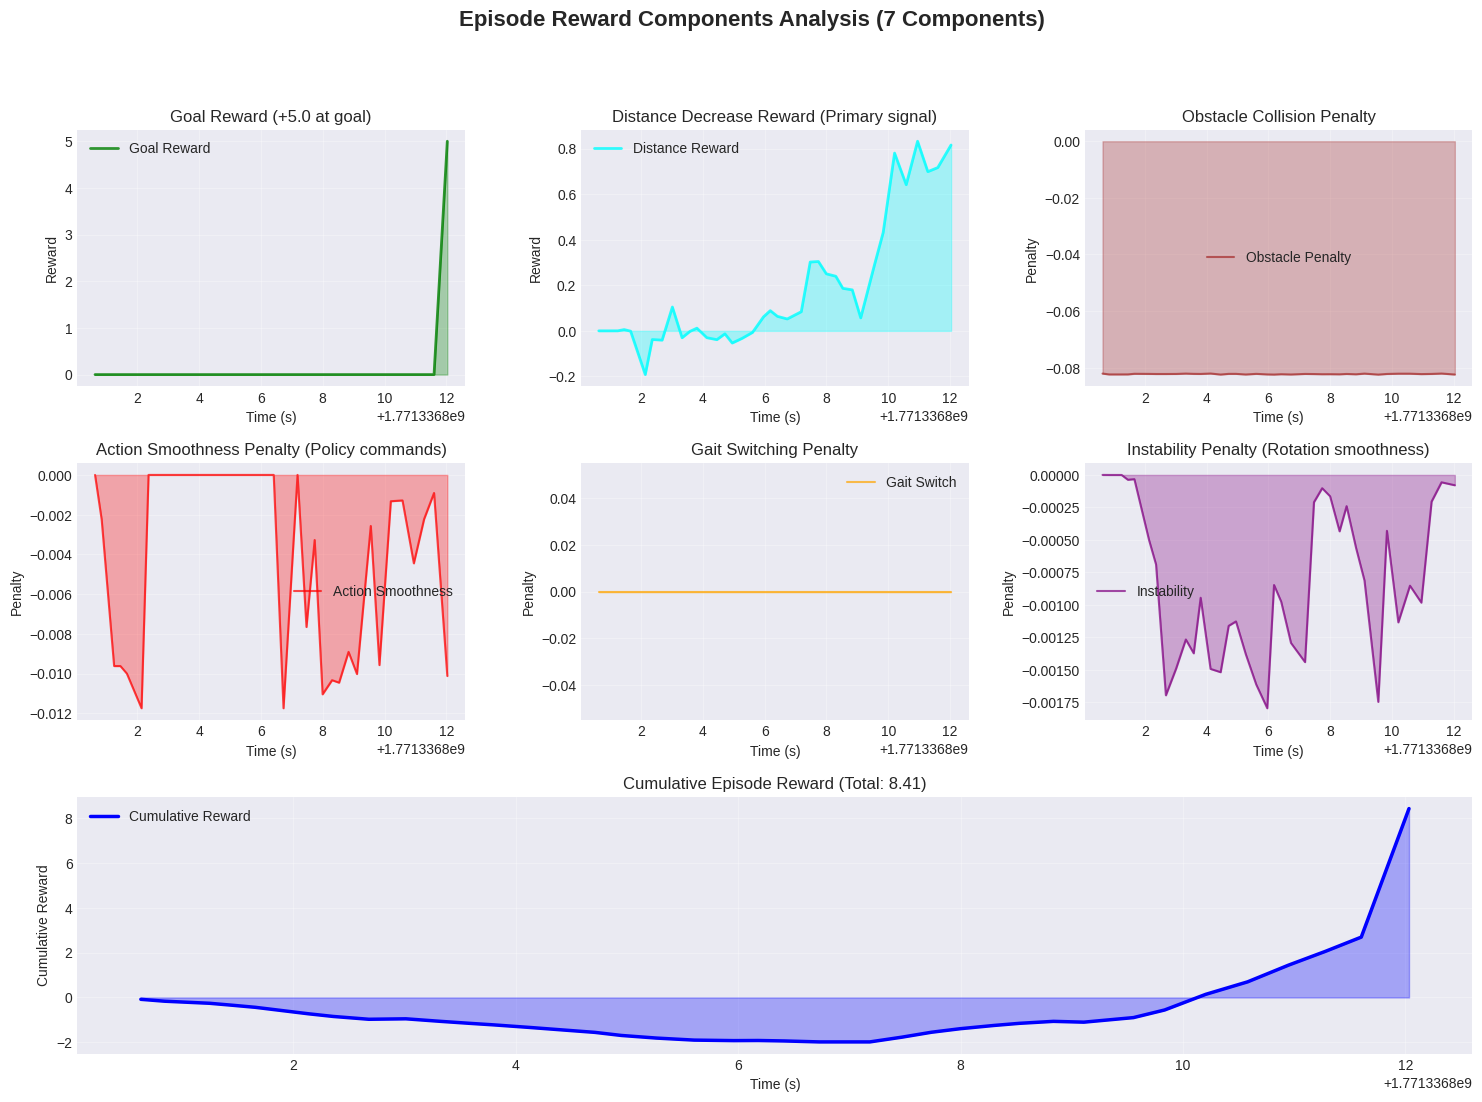

Visualization saved!


In [30]:
if episode_data and n_steps > 0:
    # Create comprehensive visualization (7 panels: 3-2-2 layout)
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle('Episode Reward Components Analysis (7 Components)', fontsize=16, fontweight='bold')
    
    # Create GridSpec for custom layout
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. Goal Reward (top left)
    ax = fig.add_subplot(gs[0, 0])
    ax.plot(timestamps_trimmed, goal_rewards, 'g-', linewidth=2, label='Goal Reward', alpha=0.8)
    ax.fill_between(timestamps_trimmed, goal_rewards, alpha=0.3, color='green')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Reward')
    ax.set_title(f'Goal Reward (+{reward_computer.goal_reward} at goal)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Distance Reward (top center)
    ax = fig.add_subplot(gs[0, 1])
    ax.plot(timestamps_trimmed, distance_rewards, 'cyan', linewidth=2, label='Distance Reward', alpha=0.8)
    ax.fill_between(timestamps_trimmed, distance_rewards, alpha=0.3, color='cyan')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Reward')
    ax.set_title('Distance Decrease Reward (Primary signal)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Obstacle Penalty (top right)
    ax = fig.add_subplot(gs[0, 2])
    ax.plot(timestamps_trimmed, obstacle_penalties, 'brown', linewidth=1.5, label='Obstacle Penalty', alpha=0.7)
    ax.fill_between(timestamps_trimmed, obstacle_penalties, alpha=0.3, color='brown')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Penalty')
    ax.set_title('Obstacle Collision Penalty')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Action Smoothness Penalty (middle left)
    ax = fig.add_subplot(gs[1, 0])
    ax.plot(timestamps_trimmed, jerk_penalties, 'r-', linewidth=1.5, label='Action Smoothness', alpha=0.7)
    ax.fill_between(timestamps_trimmed, jerk_penalties, alpha=0.3, color='red')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Penalty')
    ax.set_title('Action Smoothness Penalty (Policy commands)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 5. Gait Switching Penalty (middle center)
    ax = fig.add_subplot(gs[1, 1])
    ax.plot(timestamps_trimmed, gait_penalties, 'orange', linewidth=1.5, label='Gait Switch', alpha=0.7)
    ax.fill_between(timestamps_trimmed, gait_penalties, alpha=0.3, color='orange')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Penalty')
    ax.set_title('Gait Switching Penalty')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 6. Instability Penalty (middle right)
    ax = fig.add_subplot(gs[1, 2])
    ax.plot(timestamps_trimmed, instability_penalties, 'purple', linewidth=1.5, label='Instability', alpha=0.7)
    ax.fill_between(timestamps_trimmed, instability_penalties, alpha=0.3, color='purple')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Penalty')
    ax.set_title('Instability Penalty (Rotation smoothness)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 7. Cumulative Episode Reward (bottom, spanning full width)
    ax = fig.add_subplot(gs[2, :])
    ax.plot(timestamps_trimmed, cumulative_reward, 'b-', linewidth=2.5, label='Cumulative Reward')
    ax.fill_between(timestamps_trimmed, cumulative_reward, alpha=0.3, color='blue')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Cumulative Reward')
    ax.set_title(f'Cumulative Episode Reward (Total: {cumulative_reward[-1]:.2f})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.savefig('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/notebooks/reward_analysis.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Visualization saved!")
else:
    print("Cannot visualize: no episode data available")

In [31]:
if episode_data and n_steps > 0:
    print("=" * 70)
    print("DEBUG: OBSTACLE PENALTY DIAGNOSIS")
    print("=" * 70)
    
    if obstacle_grids is None:
        print("✗ No obstacle grids loaded!")
    else:
        print(f"\nObstacle Grids Shape: {obstacle_grids.shape}")
        print(f"Data Type: {obstacle_grids.dtype}")
        
        # Check for NaN and invalid values
        n_nan = np.isnan(obstacle_grids).sum()
        n_inf = np.isinf(obstacle_grids).sum()
        print(f"NaN values: {n_nan} / {obstacle_grids.size}")
        print(f"Inf values: {n_inf} / {obstacle_grids.size}")
        
        # Overall statistics
        valid_mask = ~(np.isnan(obstacle_grids) | np.isinf(obstacle_grids))
        if valid_mask.sum() > 0:
            print(f"\nValid (non-NaN, non-Inf) cells: {valid_mask.sum()} / {obstacle_grids.size}")
            print(f"  Min value: {obstacle_grids[valid_mask].min():.4f}")
            print(f"  Max value: {obstacle_grids[valid_mask].max():.4f}")
            print(f"  Mean value: {obstacle_grids[valid_mask].mean():.4f}")
        else:
            print("✗ All values are NaN or Inf!")
        
        # Check obstacle threshold
        robot_height_offset = -0.8
        obstacle_threshold = 0.3
        obstacle_height_threshold = robot_height_offset + obstacle_threshold  # -0.5
        
        print(f"\nObstacle Detection Settings:")
        print(f"  Robot height offset: {robot_height_offset} m")
        print(f"  Obstacle threshold: {obstacle_threshold} m above ground")
        print(f"  Detection threshold in robot coords: {obstacle_height_threshold} m")
        
        # Count obstacles above threshold in each frame
        obstacles_above_threshold_per_frame = []
        for i, grid in enumerate(obstacle_grids):
            obstacles = grid[~np.isnan(grid) & (grid > obstacle_height_threshold)]
            obstacles_above_threshold_per_frame.append(len(obstacles))
        
        obstacles_above_threshold_per_frame = np.array(obstacles_above_threshold_per_frame)
        n_frames_with_obstacles = (obstacles_above_threshold_per_frame > 0).sum()
        
        print(f"\nObstacles Above Threshold:")
        print(f"  Frames with obstacles: {n_frames_with_obstacles} / {n_steps}")
        print(f"  Mean obstacles per frame: {obstacles_above_threshold_per_frame.mean():.2f}")
        print(f"  Max obstacles in single frame: {obstacles_above_threshold_per_frame.max()}")
        
        if n_frames_with_obstacles > 0:
            # Show sample frames with obstacles
            obstacle_frame_indices = np.where(obstacles_above_threshold_per_frame > 0)[0]
            print(f"\n  First 5 frames with obstacles:")
            for idx in obstacle_frame_indices[:5]:
                grid = obstacle_grids[idx]
                obstacles = grid[~np.isnan(grid) & (grid > obstacle_height_threshold)]
                max_obs = obstacles.max()
                print(f"    Frame {idx}: {len(obstacles)} obstacles, max height={max_obs:.4f}")
        else:
            print("\n✗ NO OBSTACLES DETECTED ABOVE THRESHOLD!")
            print(f"   This could mean:")
            print(f"   1. Terrain grids contain only NaN/invalid values")
            print(f"   2. Robot never got close enough (all values < {obstacle_height_threshold})")
            print(f"   3. Grids are using a different coordinate system")
        
        # Check penalty computation directly
        print(f"\nObstacle Penalties Computed:")
        print(f"  Min penalty: {obstacle_penalties.min():.6f}")
        print(f"  Max penalty: {obstacle_penalties.max():.6f}")
        print(f"  Mean penalty: {obstacle_penalties.mean():.6f}")
        print(f"  Non-zero penalties: {(obstacle_penalties < 0).sum()} / {len(obstacle_penalties)}")
        
        if (obstacle_penalties < 0).sum() == 0:
            print("\n✗ PROBLEM: All penalties are zero!")
            print("   The obstacle_avoidance_penalty() function is not detecting obstacles.")
            print("   Check: Are obstacle_grids values in expected range?")
    
    print("=" * 70)

DEBUG: OBSTACLE PENALTY DIAGNOSIS

Obstacle Grids Shape: (38, 128, 128)
Data Type: float32
NaN values: 0 / 622592
Inf values: 0 / 622592

Valid (non-NaN, non-Inf) cells: 622592 / 622592
  Min value: -2.4324
  Max value: -0.0000
  Mean value: -2.0732

Obstacle Detection Settings:
  Robot height offset: -0.8 m
  Obstacle threshold: 0.3 m above ground
  Detection threshold in robot coords: -0.5 m

Obstacles Above Threshold:
  Frames with obstacles: 38 / 38
  Mean obstacles per frame: 1265.87
  Max obstacles in single frame: 1845

  First 5 frames with obstacles:
    Frame 0: 1206 obstacles, max height=-0.0001
    Frame 1: 1196 obstacles, max height=-0.0008
    Frame 2: 1193 obstacles, max height=-0.0008
    Frame 3: 1276 obstacles, max height=-0.0007
    Frame 4: 1463 obstacles, max height=-0.0002

Obstacle Penalties Computed:
  Min penalty: -0.082458
  Max penalty: -0.082085
  Mean penalty: -0.082271
  Non-zero penalties: 38 / 38


## Penalty Metrics Explained

### **Action Smoothness Penalty** (Red panel)

**What it measures:** How much the actor's policy commands change between consecutive timesteps.

**How it's calculated:**

1. Take the actor's action outputs at each timestep: $A_t \in \mathbb{R}^6$ (6-dimensional action vector - typically linear/angular velocities)

2. Compute the difference between consecutive actions:
   $$\Delta A_t = A_{t+1} - A_t$$

3. Calculate the magnitude of this change:
   $$||\Delta A_t|| = \sqrt{\sum_{i=1}^{6} (\Delta A_t^{i})^2}$$

4. Apply the penalty with sublinear scaling (square root softens large changes):
   $$\text{penalty}_t = -0.01 \times \sqrt{||\Delta A_t||}$$

5. Pad with one zero at the start (since we can't compute difference for the first action)

**Why sublinear?** The square root means:
- Small changes (0.1 → penalty ≈ -0.001) are lightly penalized
- Large changes (1.0 → penalty ≈ -0.01) are heavily penalized
- But a 10x change in action doesn't cause 10x penalty (√10 ≈ 3.16)

**Purpose:** Encourages the learned policy to send smooth, gradual commands rather than abrupt jerky changes. This is important because sudden action changes can be harder to execute and less stable.

---

### **Instability Penalty** (Purple panel)

**What it measures:** How much the robot's orientation (rotation) changes between consecutive timesteps.

**How it's calculated:**

1. Extract the robot's orientation as a quaternion: $q_t = [q_x, q_y, q_z, q_w]$ (from state vector)

2. Compute quaternion change between timesteps:
   $$\Delta q_t = q_{t+1} - q_t$$

3. Calculate the magnitude of quaternion change:
   $$||\Delta q_t|| = \sqrt{q_x^2 + q_y^2 + q_z^2 + q_w^2}$$

4. Apply the penalty (linear scaling):
   $$\text{penalty}_t = -0.1 \times ||\Delta q_t||$$

5. Pad with one zero at the start

**Why quaternion magnitude?** 
- Quaternions represent 3D rotations
- The magnitude of change correlates with how fast the robot is rotating
- Large quaternion changes = large angular velocity = unstable/jerky motion

**Purpose:** Encourages the robot to maintain a stable orientation without rolling, pitching, or yawing excessively. This is complementary to action smoothness:
- **Action smoothness** = smooth policy outputs
- **Instability** = smooth actual motion (penalizes the outcome)

Together they push the learned policy toward producing both smooth commands AND stable motion outcomes.

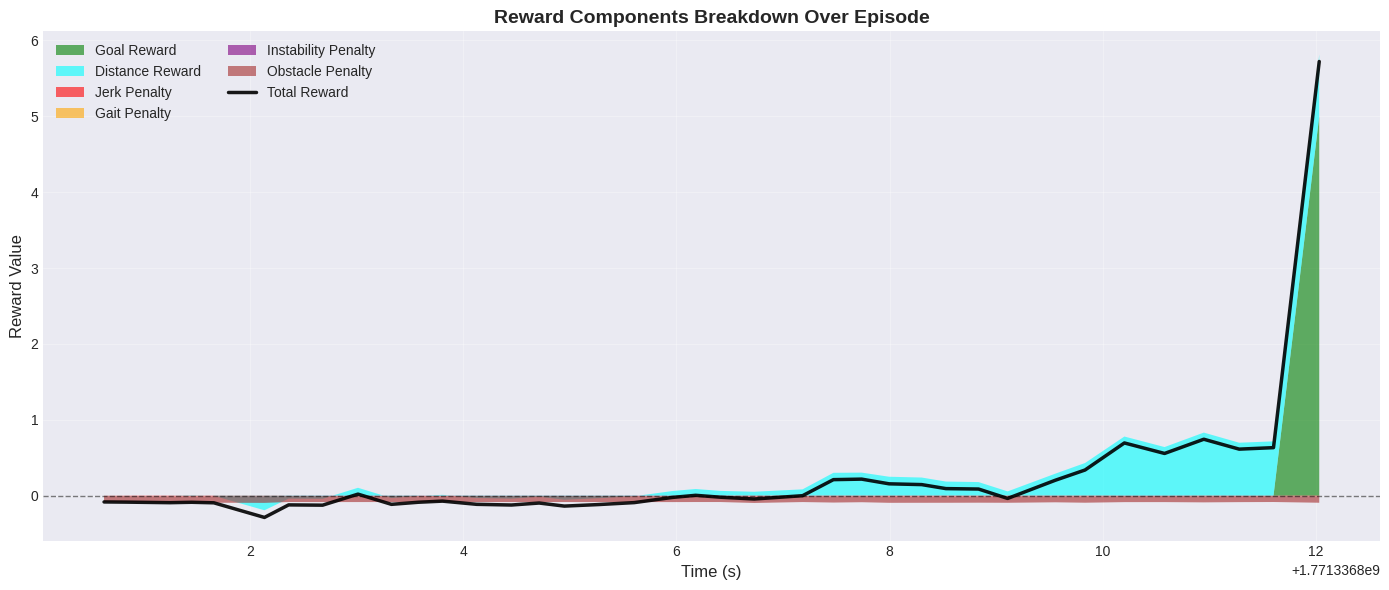

Breakdown visualization saved!


In [32]:
# Additional: Detailed reward breakdown by component
if episode_data and n_steps > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Separate positive and negative rewards for better visualization
    ax.stackplot(timestamps_trimmed, 
                goal_rewards,
                distance_rewards,
                labels=['Goal Reward', 'Distance Reward'],
                colors=['green', 'cyan'],
                alpha=0.6)
    
    ax.stackplot(timestamps_trimmed,
                jerk_penalties,
                gait_penalties,
                instability_penalties,
                obstacle_penalties,
                labels=['Jerk Penalty', 'Gait Penalty', 'Instability Penalty', 'Obstacle Penalty'],
                colors=['red', 'orange', 'purple', 'brown'],
                alpha=0.6)
    
    ax.plot(timestamps_trimmed, total_rewards, 'k-', linewidth=2.5, label='Total Reward', alpha=0.9)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Reward Value', fontsize=12)
    ax.set_title('Reward Components Breakdown Over Episode', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10, ncol=2)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/notebooks/reward_breakdown.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Breakdown visualization saved!")
else:
    print("Cannot visualize: no episode data available")

In [33]:
# Summary statistics table
if episode_data and n_steps > 0:
    summary_stats = pd.DataFrame({
        'Metric': ['Count', 'Mean', 'Std Dev', 'Min', 'Max', 'Total'],
        'Goal Reward': [
            np.count_nonzero(goal_rewards),
            np.mean(goal_rewards),
            np.std(goal_rewards),
            np.min(goal_rewards),
            np.max(goal_rewards),
            np.sum(goal_rewards)
        ],
        'Distance Reward': [
            np.count_nonzero(distance_rewards),
            np.mean(distance_rewards),
            np.std(distance_rewards),
            np.min(distance_rewards),
            np.max(distance_rewards),
            np.sum(distance_rewards)
        ],
        'Action Smoothness': [
            np.count_nonzero(jerk_penalties),
            np.mean(jerk_penalties),
            np.std(jerk_penalties),
            np.min(jerk_penalties),
            np.max(jerk_penalties),
            np.sum(jerk_penalties)
        ],
        'Gait Penalty': [
            np.count_nonzero(gait_penalties),
            np.mean(gait_penalties),
            np.std(gait_penalties),
            np.min(gait_penalties),
            np.max(gait_penalties),
            np.sum(gait_penalties)
        ],
        'Instability Penalty': [
            np.count_nonzero(instability_penalties),
            np.mean(instability_penalties),
            np.std(instability_penalties),
            np.min(instability_penalties),
            np.max(instability_penalties),
            np.sum(instability_penalties)
        ],
        'Total Reward': [
            n_steps,
            np.mean(total_rewards),
            np.std(total_rewards),
            np.min(total_rewards),
            np.max(total_rewards),
            np.sum(total_rewards)
        ]
    })
    
    print("\nReward Summary Statistics:")
    print(summary_stats.to_string(index=False))
    
    # Export to CSV
    rewards_df.to_csv('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/notebooks/rewards.csv', index=False)
    print("\nRewards data exported to: rewards.csv")


Reward Summary Statistics:
 Metric  Goal Reward  Distance Reward  Action Smoothness  Gait Penalty  Instability Penalty  Total Reward
  Count     1.000000        37.000000          21.000000           0.0            37.000000     38.000000
   Mean     0.131579         0.176736          -0.003925           0.0            -0.000809      0.221310
Std Dev     0.800363         0.277188           0.004582           0.0             0.000592      0.940140
    Min     0.000000        -0.191869          -0.011746           0.0            -0.001798     -0.286332
    Max     5.000000         0.831981          -0.000000           0.0             0.000000      5.722933
  Total     5.000000         6.715963          -0.149149           0.0            -0.030728      8.409778

Rewards data exported to: rewards.csv
